# Chapter 5

c:\Users\aveek\anaconda3\envs\py37\lib\site-packages\ipykernel_launcher.py:40: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().


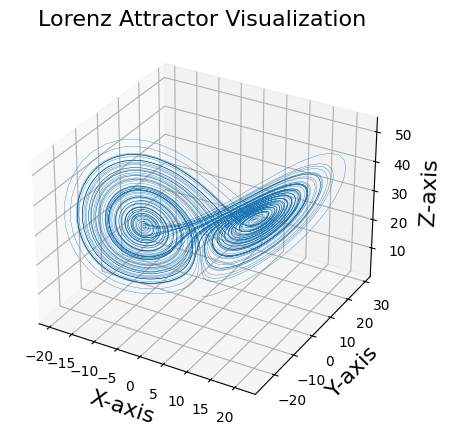

In [ ]:
# Visualize Lorenz Attractor [Piziniacco. L, 2020]

import numpy as np
import matplotlib.pyplot as plt

beta = 2.66667
rho = 28.0
sigma = 10.0


def lorenz(x, y, z, beta, rho, sigma):
    Xdt = (sigma*y) - (sigma*x)
    Ydt = -(x*z) + (rho*x) - y
    Zdt = (x*y) - (beta*z)
    return Xdt, Ydt, Zdt


dT = 0.01
iteration = 10000

x_out = np.zeros(iteration)
y_out = np.zeros(iteration)
z_out = np.zeros(iteration)   

# starting point
x_out[0] = 0
y_out[0] = 1
z_out[0] = 1.05


for i in range(iteration - 1):
    curr_x, curr_y, curr_z = lorenz(x_out[i], y_out[i], z_out[i], beta, rho, sigma)
    x_out[i+1] = x_out[i] + (curr_x*dT) 
    y_out[i+1] = y_out[i] + (curr_y*dT) 
    z_out[i+1] = z_out[i] + (curr_z*dT) 
    
# Plot
fontdict={'size':16,}
fig1 = plt.figure(figsize=(5,5))
ax = fig1.gca(projection='3d')
ax.plot(x_out, y_out, z_out, lw=0.25)

ax.set_xlabel("X-axis", fontdict)
ax.set_ylabel("Y-axis", fontdict)
ax.set_zlabel("Z-axis", fontdict)
ax.set_title("Lorenz Attractor Visualization", fontdict)

plt.show()

c:\Users\aveek\anaconda3\envs\py37\lib\site-packages\ipykernel_launcher.py:14: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  


Text(0.5, 0.92, 'Attractor Reconstruction from lagged X-values')

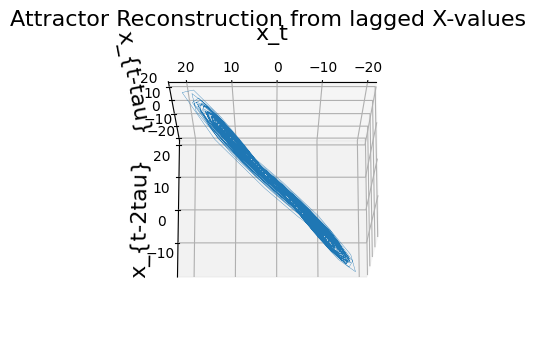

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline 

# lagged values of X from the Lorenz Attractor
xt   = x_out[:-2:5]
xt_1 = x_out[1:-1:5]
xt_2 = x_out[2::5]

# Plot
fontdict={'size':16,}
fig2 = plt.figure(figsize=(6,4))
ax = fig2.gca(projection='3d')
ax.plot(xt, xt_1, xt_2, lw=0.25)

ax.view_init(-15, 90)
ax.set_xlabel("x_t", fontdict)
ax.set_ylabel("x_{t-tau}", fontdict)
ax.set_zlabel("x_{t-2tau}", fontdict)
ax.set_title("Attractor Reconstruction from lagged X-values", fontdict)




In [ ]:
# Install pyEDM
!pip install pyEDM

In [ ]:
# Import libraries
import numpy as np
from numpy.random import default_rng
import pandas as pd
from pandas.plotting import autocorrelation_plot
import scipy.stats as st
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from pyEDM import *
%matplotlib inline
rng = default_rng()

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
# generate TentMap timeseries

def gen_TentMap(n=1000):  
    tentmap = np.zeros(n)
    tentmap[0] = rng.random()
    r = 1.999

    for i in range(n-1):
        if tentmap[i] < 0.5:
            tentmap[i+1] = r * tentmap[i]
        else:
            tentmap[i+1] = r *(1 - tentmap[i])
    
    return tentmap
        
tentmap = gen_TentMap()
tentmap = np.diff(tentmap)
time_index = np.arange(len(tentmap))
tentmap_list  = list(zip(time_index, tentmap))

tentmap_df = pd.DataFrame(tentmap_list, columns=["Time", "TentMap"])
tentmap_df.head()

,Time,TentMap
0,0,-0.744967
1,1,0.169824
2,2,0.339477
3,3,-0.038204
4,4,0.076369


Text(0, 0.5, '$\\mathbf{\\Delta_t}}$')

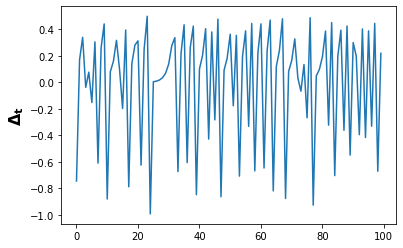

In [ ]:
# plot the first 100 values to visualize the timeseries

pd.Series(tentmap_df["TentMap"][0:100]).plot()
plt.ylabel('$\mathbf{\Delta_t}}$', size=16)

In [ ]:
# check for stationarity of the first-difference TentMap time-series

from statsmodels.tsa.stattools import adfuller

result = adfuller(tentmap_df["TentMap"])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -12.341769
p-value: 0.000000
Critical Values:
	1%: -3.437
	5%: -2.865
	10%: -2.568


In [ ]:
# Compute for correlation coefficient for increasing Tp (timestep window)
corr_coeff_tentmap = []
for Tp in np.arange(1,11):
    simplex_out = Simplex( dataFrame = tentmap_df, lib = "1 400", pred = "450 800",  E = 3, Tp=Tp, embedded = False, showPlot = False, columns="TentMap", target="TentMap")
    metrics = pyEDM.ComputeError(simplex_out.Observations, simplex_out.Predictions)
    corr_coeff_tentmap.append(metrics['rho'])

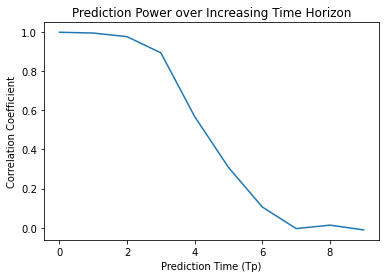

In [ ]:
# corr_coeff_tentmap = [1.0, 1.0, 0.98, .88, 0.61, 0.35, 0.19, 0.08, 0.06, 0.02]
pd.Series(corr_coeff_tentmap).plot()
plt.ylabel('Correlation Coefficient')
plt.xlabel('Prediction Time (Tp)')
plt.title('Prediction Power over Increasing Time Horizon')
plt.show()

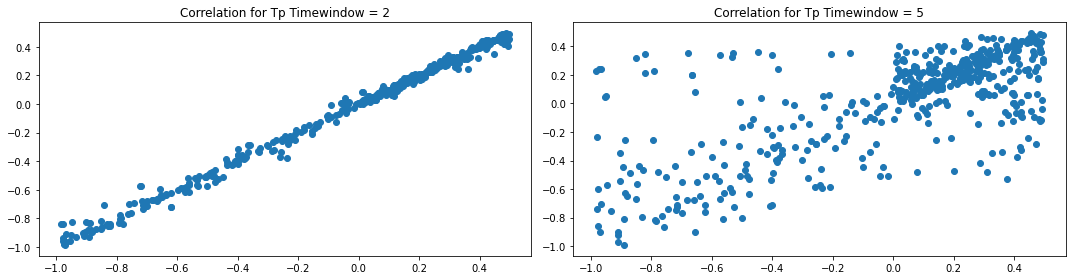

In [ ]:
simplex_out_2 = Simplex( dataFrame = tentmap_df, lib = "1 500", pred = "501 999",  E = 3, Tp=2, embedded = False, showPlot = False, columns="TentMap", target="TentMap")
simplex_out_5 = Simplex( dataFrame = tentmap_df, lib = "1 500", pred = "501 999",  E = 3, Tp=5, embedded = False, showPlot = False, columns="TentMap", target="TentMap")

plt.figure(figsize=(15, 4))

plt.subplot(121)
plt.scatter(simplex_out_2.Observations[2:498], simplex_out_2.Predictions[2:498])
plt.title("Correlation for Tp Timewindow = 2")

plt.subplot(122)
plt.scatter(simplex_out_5.Observations[2:498], simplex_out_5.Predictions[2:498])
plt.title("Correlation for Tp Timewindow = 5")

plt.tight_layout()

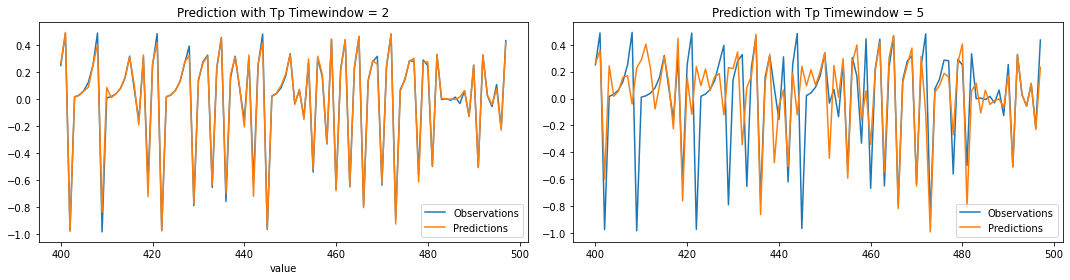

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(121)
plt.plot(simplex_out_2.Observations[400:498], label='Observations')
plt.plot(simplex_out_2.Predictions[400:498], label='Predictions')
plt.xlabel("value")
plt.legend()
plt.title("Prediction with Tp Timewindow = 2")


plt.subplot(122)
plt.plot(simplex_out_5.Observations[400:498], label="Observations")
plt.plot(simplex_out_5.Predictions[400:498], label="Predictions")
plt.legend()
plt.title("Prediction with Tp Timewindow = 5")


plt.tight_layout()

NameError: name 'pd' is not defined

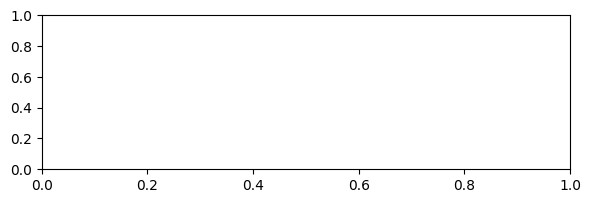

In [ ]:
#Plots of sine waves corrupted by noise and tent map time series

plt.figure(figsize=(15, 2))

plt.subplot(121)
noisysine_df = pd.DataFrame()
noisysine_df['Time'] = np.arange(1,1001)
noisysine_df['Data'] = np.sin(0.5*noisysine_df['Time']) - np.random.uniform(low=-0.5, high=0.5, size=1000)
pd.Series(noisysine_df['Data'][1:100]).plot()
plt.title("Regular SineWave - Noise Corrupted")

plt.subplot(122)
tentMap2 = gen_TentMap() + gen_TentMap()
tentMap2_df = pd.DataFrame()
tentMap2_df["Time"] = np.arange(1,1001)
tentMap2_df["Data"] = pd.Series(tentMap2)
plt.plot(tentMap2_df.Data[10:60])
plt.title("Additive TentMap - Chaotic Signal")

In [ ]:
corr_coeff_sinemap = []
corr_coeff_tentmap = []
for Tp in np.arange(11):
    simplex_out = Simplex( dataFrame = noisysine_df, lib = "1 150", pred = "501 999",  E = 3, Tp=Tp, embedded = False, showPlot = False, columns="Data", target="Data")
    metrics = pyEDM.ComputeError(simplex_out.Observations, simplex_out.Predictions)
    corr_coeff_sinemap.append(metrics['rho'])
    
    simplex_tent = Simplex( dataFrame = tentMap2_df, lib = "1 150", pred = "501 999",  E = 3, Tp=Tp, embedded = False, showPlot = False, columns="Data", target="Data")
    metrics = pyEDM.ComputeError(simplex_tent.Observations, simplex_tent.Predictions)
    corr_coeff_tentmap.append(metrics['rho'])
    

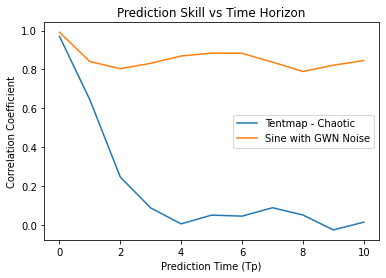

In [ ]:
# corr_coeff_sinemap = [0.83, 0.81, 0.8, 0.83, 0.87, 0.86, 0.83, 0.78, 0.8, 0.83]
# corr_coeff_tentmap = [1.0, 1.0, 0.98, .88, 0.61, 0.35, 0.19, 0.08, 0.06, 0.02]
pd.Series(corr_coeff_tentmap).plot(label="Tentmap - Chaotic")
pd.Series(corr_coeff_sinemap).plot(label= "Sine with GWN Noise")
plt.ylabel('Correlation Coefficient')
plt.xlabel('Prediction Time (Tp)')
plt.title("Prediction Skill vs Time Horizon")
plt.legend(loc='best')
plt.show()


In [ ]:
# let's define a number of possible embeddings/projections/dimensions
embeds = np.arange(2,11)
data = tentmap_df

# output metrics for each embedding value
MAE = [] # Mean Absolute Error
rho = [] # Pearson correlation
RMSE = [] # Root-Mean Square Error

for e in embeds:
  simplex_result = pyEDM.Simplex(dataFrame=data, E=e, lib="1 100" , pred="201 500" , columns='TentMap', target='TentMap')
  metrics = pyEDM.ComputeError(simplex_result.Observations, simplex_result.Predictions)
  MAE.append(metrics['MAE'])
  rho.append(metrics['rho'])
  RMSE.append(metrics['RMSE'])


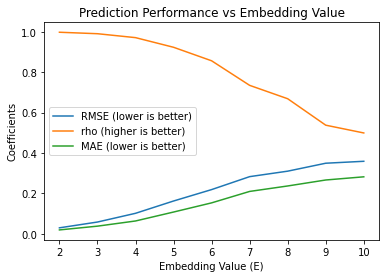

In [ ]:
pd.Series(RMSE).plot(label='RMSE (lower is better)') 
pd.Series(rho).plot(label='rho (higher is better)') 
pd.Series(MAE).plot(label='MAE (lower is better)') 

x = np.arange(9)
plt.xticks(x, embeds)
plt.xlabel('Embedding Value (E)')
plt.ylabel('Coefficients')
plt.legend(loc='best')
plt.title("Prediction Performance vs Embedding Value")
plt.show()



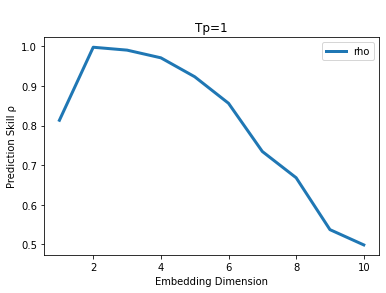

      E       rho
0   1.0  0.813284
1   2.0  0.997519
2   3.0  0.990242
3   4.0  0.970822
4   5.0  0.923086
5   6.0  0.856189
6   7.0  0.734546
7   8.0  0.668289
8   9.0  0.537366
9  10.0  0.498850


In [ ]:
optimal_emdedding = pyEDM.EmbedDimension(dataFrame=tentmap_df, lib="1 100" , pred="201 500" , columns='TentMap', target='TentMap')
print(optimal_emdedding)

# Optimal embedding value E = 2 for Time Horizon, Tp = 1

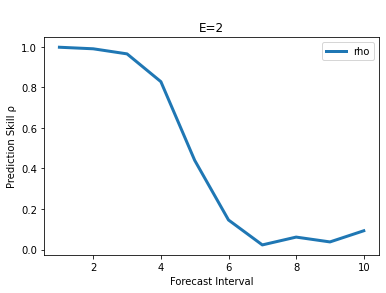

In [ ]:
data = tentmap_df
rho_Tp = pyEDM.PredictInterval(dataFrame=data, lib="1 100" , pred="201 500" , columns='TentMap', target='TentMap', E = 2)

In [ ]:
# Generate a Guassian White Noise Signal

noise_map = pd.Series(np.random.normal(size=1000), name='GWN').to_frame()
time_map = pd.Series(np.arange(1,1000), name='Time').to_frame()
noisy_data = pd.concat([time_map, noise_map], axis= 1)

In [ ]:
# let's define a number of possible embeddings/projections/dimensions
embeds = np.arange(2,11)
data = noisy_data

# output metrics for each embedding value
MAE = [] # Mean Absolute Error
rho = [] # Pearson correlation
RMSE = [] # Root-Mean Square Error

for e in embeds:
  simplex_result = pyEDM.Simplex(dataFrame=data, E=e, lib="1 100" , pred="201 500" , columns='GWN', target='GWN')
  metrics = pyEDM.ComputeError(simplex_result.Observations, simplex_result.Predictions)
  MAE.append(metrics['MAE'])
  rho.append(metrics['rho'])
  RMSE.append(metrics['RMSE'])


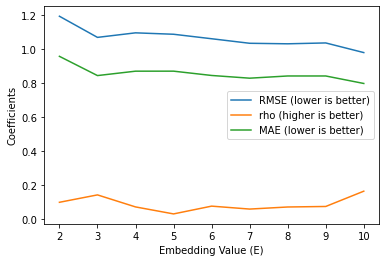

In [ ]:
pd.Series(RMSE).plot(label='RMSE (lower is better)') 
pd.Series(rho).plot(label='rho (higher is better)') 
pd.Series(MAE).plot(label='MAE (lower is better)') 

x = np.arange(9)
plt.xticks(x, embeds)
plt.xlabel('Embedding Value (E)')
plt.ylabel('Coefficients')
plt.legend(loc='best')
plt.show()

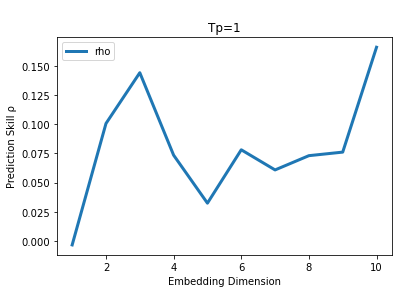

      E       rho
0   1.0 -0.003498
1   2.0  0.100611
2   3.0  0.144132
3   4.0  0.073450
4   5.0  0.032297
5   6.0  0.078051
6   7.0  0.060788
7   8.0  0.073014
8   9.0  0.076058
9  10.0  0.165966


In [ ]:
optimal_emdedding = pyEDM.EmbedDimension(dataFrame=data, lib="1 100" , pred="201 500" , columns='GWN', target='GWN')
print(optimal_emdedding)

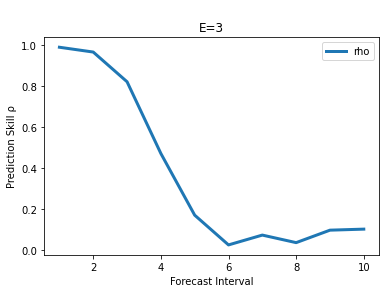

In [ ]:
data = tentmap_df
rho_Tp = pyEDM.PredictInterval(dataFrame=data, lib="1 100" , pred="201 500" , columns='TentMap', target='TentMap', E = 3)

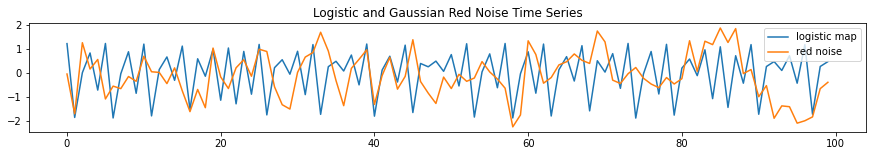

In [ ]:
# Read Data and Normalize / Plot
smap_df = pd.read_csv(filepath_or_buffer='../data/ESM2_Data_noise.csv')
smap_df['R'] = (smap_df['R'] - np.mean(smap_df['R']))/np.std(smap_df['R'])
smap_df['L'] = (smap_df['L'] - np.mean(smap_df['L']))/np.std(smap_df['L'])
smap_df['T'] = pd.Series(np.arange(1,10001))
smap_df = smap_df[['T', 'R', 'L']]

plt.figure(figsize=(15, 2))

# pd.Series(smap_df['R'][0:100]).plot(color='r', label='red noise')
# pd.Series(smap_df['L'][0:100]).plot(color='b', label='logistic map')

pd.Series(smap_df['L'][0:100]).plot(label='logistic map')
pd.Series(smap_df['R'][0:100]).plot(label='red noise')
plt.title('Logistic and Gaussian Red Noise Time Series')

plt.legend(loc='best')

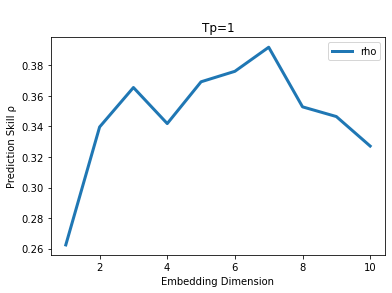

In [ ]:
# Determining Optimal Embedding Dimension for Gaussian Red Noise
data = smap_df
optimal_emdedding_red_noise = pyEDM.EmbedDimension(dataFrame=data, lib="1 500" , pred="501 1000" , columns='R', target='R')

# Optimal Embedding Dimension for Gaussian Red Noise, E = 7

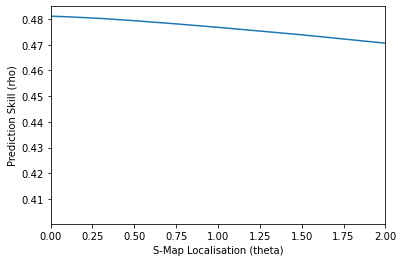

In [ ]:
# Gaussian Red Noise
# Use Optimal Embedding from above, E = 7
# Analyze Prediction Skill
preds = pyEDM.PredictNonlinear(dataFrame=smap_df, E=7, lib="1 500" , pred="501 1000" , columns='R', target='R', showPlot=False)
plt.plot(preds['Theta'], preds['rho'])
plt.xlim(0, 2)
plt.ylabel('Prediction Skill (rho)')
plt.xlabel('S-Map Localisation (theta)')
plt.show()

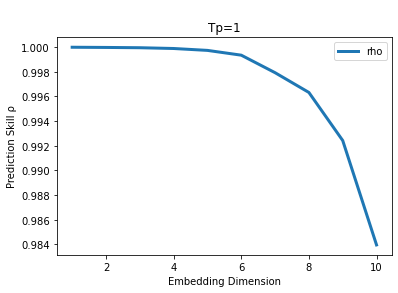

In [ ]:
# Determining Optimal Embedding Dimension for the Logistic Map
data = smap_df
optimal_emdedding_log_map = pyEDM.EmbedDimension(dataFrame=data, lib="1 500" , pred="501 1000" , columns='L', target='L')

# Optimal Embedding Dimension for Logistic Map, E = 2

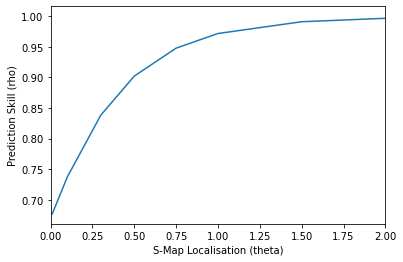

In [ ]:
# Logistic Map
# Use Optimal Embedding from above, E = 2
# Analyze Prediction Skill
preds = pyEDM.PredictNonlinear(dataFrame=smap_df, E=2, lib="1 500" , pred="501 1000" , columns='L', target='L', showPlot=False)
plt.xlim([0, 2])
plt.plot(preds['Theta'], preds['rho'])
plt.ylabel('Prediction Skill (rho)')
plt.xlabel('S-Map Localisation (theta)')
plt.show()

In [ ]:
uni_df = pd.read_csv(filepath_or_buffer='../data/5 specie data set.csv', index_col=False)
uni_df['Time'] = pd.Series(np.arange(2000))
uni_df = uni_df[['Time', 'R', 'C1', 'C2','P1', 'P2']]
uni_df.head()

,Time,R,C1,C2,P1,P2
0,0,0.562018,0.002226,1.815200,0.006884,0.087266
1,1,0.238250,0.002987,1.913687,0.004210,0.137499
2,2,0.063778,0.002384,1.275531,0.002576,0.210435
3,3,0.153577,0.001665,0.692132,0.001572,0.286715
4,4,0.860214,0.002310,0.578684,0.000959,0.352087


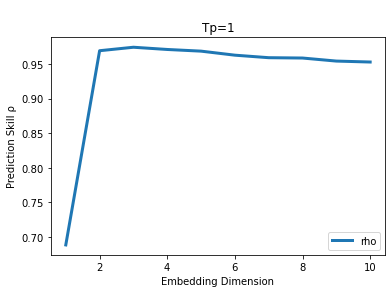

      E       rho
0   1.0  0.688288
1   2.0  0.969399
2   3.0  0.974422
3   4.0  0.971195
4   5.0  0.968775
5   6.0  0.962940
6   7.0  0.959300
7   8.0  0.958808
8   9.0  0.954404
9  10.0  0.953030


In [ ]:
optimal_emdedding = pyEDM.EmbedDimension(dataFrame=uni_df, lib="1 1000" , pred="1001 1999" , columns='C1', target='C1')
print(optimal_emdedding)

In [ ]:
simplex_out_uni = Simplex( dataFrame =uni_df, lib = "1 1000", pred = "1001 1999",  E = 3, Tp=1, embedded = False, showPlot = False, columns="C1", target="C1")

In [ ]:
simplex_out_uni.head(5)

,Time,Observations,Predictions,Pred_Variance
0,1000,0.226670,NaN,NaN
1,1001,0.433118,0.415078,0.002822
2,1002,0.843978,0.728465,0.010937
3,1003,1.465515,1.402749,0.052009
4,1004,1.413874,1.747335,0.008604


Text(0.5, 1.0, 'Prediction with Embedding E = 3')

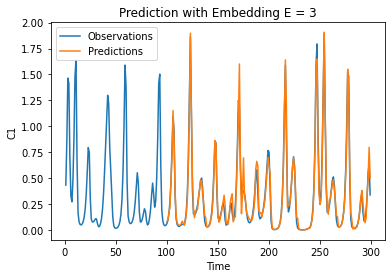

In [ ]:
# Plot of Predictions vs Observations

plt.plot(simplex_out_uni.Observations[1:300], label='Observations')
plt.plot(simplex_out_uni.Predictions[100:300], label='Predictions')
plt.xlabel("Time")
plt.ylabel("C1")
plt.legend()
plt.title("Prediction with Embedding E = 3")

In [ ]:
multivariate_out = Simplex( dataFrame =uni_df, lib = "1 200", pred = "500 700", E = 3, Tp=1, embedded = False, showPlot = False, columns="R P1 C1", target="C1")

In [ ]:
multivariate_out.head(5)

,Time,Observations,Predictions,Pred_Variance
0,499,0.879706,NaN,NaN
1,500,0.981080,1.157826,0.031553
2,501,0.694387,1.009867,0.114386
3,502,0.150185,0.228026,0.021878
4,503,0.013382,0.049704,0.003086


Text(0.5, 1.0, 'Prediction with Embedding E = 3')

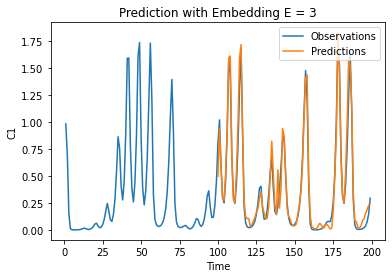

In [ ]:
plt.plot(multivariate_out.Observations[1:200], label='Observations')
plt.plot(multivariate_out.Predictions[100:200], label='Predictions')
plt.xlabel("Time")
plt.ylabel("C1")
plt.legend()
plt.title("Prediction with Embedding E = 3")

In [ ]:
multiview_out = pyEDM.Multiview(dataFrame =uni_df, lib = "1 200", pred = "500 700",  E = 3, Tp=1, showPlot = False, columns="R C1 C2 P1 P2", target="C1")

Text(0.5, 1.0, 'Prediction with Embedding E = 3')

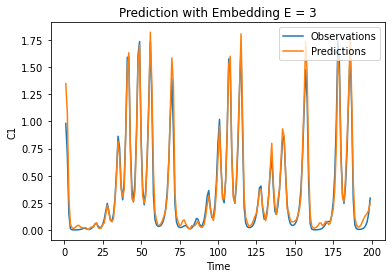

In [ ]:
plt.plot(multiview_out['Predictions'].Observations[1:200], label='Observations')
plt.plot(multiview_out['Predictions'].Predictions[1:200], label='Predictions')
plt.xlabel("Time")
plt.ylabel("C1")
plt.legend()
plt.title("Prediction with Embedding E = 3")

## Application to the Jenna Climate Dataset

In [ ]:
# Import Libraries
import numpy as np
from numpy.random import default_rng
import pandas as pd
from pandas.plotting import autocorrelation_plot
import scipy.stats as st
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm
from pyEDM import *
%matplotlib inline
rng = default_rng()


In [ ]:
# read training data and test data
train_df = pd.read_csv(filepath_or_buffer='../data/train_series.csv')
test_df = pd.read_csv(filepath_or_buffer='../data/test_series.csv')
val_df = pd.read_csv(filepath_or_buffer='../data/val_series.csv')



In [ ]:
# Print sizes
print("Training Set Size: {}".format(train_df.shape))
print("Validation Set Size: {}".format(val_df.shape))
print("Test Set Size: {}".format(test_df.shape))


Training Set Size: (35045, 15)
Validation Set Size: (17524, 15)
Test Set Size: (17523, 15)


In [ ]:
## Concatenate the Dataframes into one

climate_df = pd.concat([train_df, val_df, test_df])

In [ ]:
# Drop other columns
climate_df = climate_df.drop(climate_df.columns[3:], axis=1)
climate_df = climate_df.drop(climate_df.columns[1], axis=1)

# Rename first column to "Time", the Temperature into a friendly string
climate_df = climate_df.rename(columns = {'T (degC)': 'Temperature'})
climate_df = climate_df.rename(columns = {'Unnamed: 0': 'Time'})
climate_df.reset_index(drop=True)


,Time,Temperature
0,0,-8.02
1,6,-7.62
2,12,-8.85
3,18,-8.84
4,24,-9.23
...,...,...
70087,420522,-1.40
70088,420528,-2.15
70089,420534,-2.61
70090,420540,-3.22


Text(0, 0.5, 'Temperature (C) - Training Plus Validation')

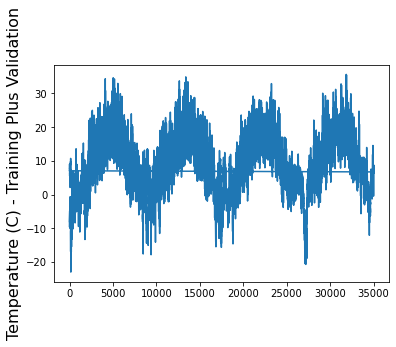

In [ ]:
# plot the training set and testing set combined

data_size = train_df.shape[0] + val_df.shape[0]
pd.Series(climate_df["Temperature"][0:data_size]).plot()
plt.ylabel('Temperature (C) - Training Plus Validation', size=16)

Text(0, 0.5, 'Temperature (C) - Test')

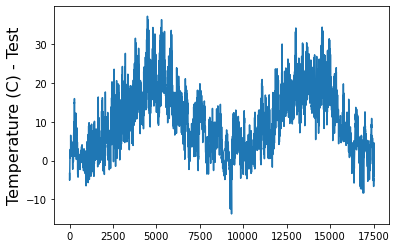

In [ ]:
# plot the test set

pd.Series(climate_df["Temperature"][data_size:]).plot()
plt.ylabel('Temperature (C) - Test', size=16)

In [ ]:
# quick check for stationarity in the training set and testing set

from statsmodels.tsa.stattools import adfuller

result = adfuller(climate_df["Temperature"][0:data_size])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))
    
# quick test shows stationarity 

ADF Statistic: -7.958617
p-value: 0.000000
Critical Values:
	1%: -3.430
	5%: -2.862
	10%: -2.567


##### Hyperparameter Tuning (Calculation of Optimal Embedding)

100%|██████████| 100/100 [04:37<00:00,  2.78s/it]


<AxesSubplot:xlabel='E'>

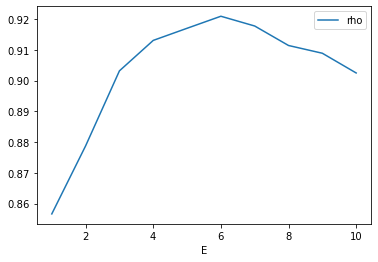

In [ ]:
# Calculate Optimal Embedding by looking at various time chunks

rho_values = pd.DataFrame(data=np.zeros((10,2)), columns = ['E', 'rho'])
# starting row of validation data 
start_pt = 35046 
num_blocks = 100


for i in tqdm(range(num_blocks)):
    starting = (24*i) + start_pt
    ending = starting + 24 - 1
    preds = str(starting) + " " + str(ending)
    starting = ending + 1

    current_rho = pyEDM.EmbedDimension(dataFrame=climate_df, lib="1 35045" , pred=preds , columns='Temperature', target='Temperature', showPlot=False)
    rho_values.rho = rho_values.rho + current_rho.rho
    rho_values.E = current_rho.E

rho_values.rho = rho_values.rho / num_blocks
rho_values.plot('E', 'rho')


In [ ]:
# Calculate optimal embedding E using all values (not by chunks)
# time period is from 35046 to 52326

rho_whole = pyEDM.EmbedDimension(dataFrame=climate_df, lib="1 35045" , pred="35046 52326" , columns='Temperature', target='Temperature', showPlot=False)
rho_whole.plot('E', 'rho')

##### Computation of MAE using Simplex Projection Method

In [ ]:
MAE = []
e = 6
start_pt = 52570
num_blocks = 100
for i in tqdm(range(num_blocks)):
    starting = (24*i) + start_pt
    ending = starting + 24 - 1
    preds = str(starting) + " " + str(ending)
    starting = ending + 1

    climate_result = pyEDM.Simplex(dataFrame=climate_df, lib="1 35045", pred=preds, Tp=24, columns="Temperature", target="Temperature", E = e, showPlot=False)
    mae_current = mean_absolute_error(climate_result.Observations[:24].to_numpy(), climate_result.Predictions[24:].to_numpy())
    MAE.append(mae_current)

100%|██████████| 100/100 [00:16<00:00,  6.11it/s]


In [ ]:
np.mean(MAE)

1.2339145175433177

In [ ]:
# Forecast Interval / Prediction Decay
rho_Tp = pyEDM.PredictInterval(dataFrame=train_val_df, lib="1 35044" , pred="35046 35070" , columns='Temperature', target='Temperature', E = 6)


##### Computation of MAE using the SMap Method

In [ ]:
MAE_smap = []
e = 6
start_pt = 52570
num_blocks = 100
for i in tqdm(range(num_blocks)):
    starting = (24*i) + start_pt
    ending = starting + 24 - 1
    preds = str(starting) + " " + str(ending)
    starting = ending + 1

    climate_result = pyEDM.SMap(dataFrame=climate_df, lib="1 35045", pred=preds, Tp=24, columns="Temperature", target="Temperature", E = e, theta = 0.03, showPlot=False)
#     print(climate_result['predictions'].Observations)
    mae_current = mean_absolute_error(climate_result['predictions'].Observations[:24].to_numpy(), climate_result['predictions'].Predictions[24:].to_numpy())
    MAE_smap.append(mae_current)

100%|██████████| 100/100 [00:32<00:00,  3.10it/s]


In [ ]:
np.mean(MAE_smap)

0.5050182906423609

In [ ]:
# Predict Nonlinearity

rho_Theta = pyEDM.PredictNonlinear(dataFrame=train_val_df, lib="1 35045" , pred="35046 35070" , columns='Temperature', target='Temperature', showPlot=False)
rho_Theta.plot('Theta', 'rho')



## Summary

- Simplex and SMaps are non-parametric methods of analyzing and predicting time-series, especially in dynamic systems where chaos might be present
- Both methods use lagged-values to reconstruct a manifold in higher dimensional space, and use various iterations of nearest neighbor methods to predict location of points in the manifold
- Since it is not parametric, there is a need to recreate the library everytime a prediction is to be done, increasing computatonal complexity

